In [42]:
import numpy as np
import dill as pickle
import matplotlib
import corner
from matplotlib import pyplot as plt
from pkg_resources import resource_filename
from scipy.stats import gaussian_kde
from scipy import optimize
import cue
from cue.line import predict
from cue.utils import (c, cont_lam, new_sorted_line_name, 
                       logQ, Qtotal,
                       get_loglinear_spectra, ionparam2norm, calcQ) # this includes some constants and functions for the fits and output plots

In [43]:
galaxy = "fC23"

# use observations from fluxSN, no matter what. these are the files that actually include HB. 
with open("line_luminosities_test/"+galaxy+"_fluxSN.pkl", 'rb') as f:
    fluxSN_obs = pickle.load(f)

with open("line_luminosities_test/"+galaxy+".pkl", 'rb') as f:
    test_obs = pickle.load(f)

with open("line_luminosities/"+galaxy+".pkl", 'rb') as f:
    og_obs = pickle.load(f)


In [44]:
print(fluxSN_obs["line_name"][(fluxSN_obs["line_lum_up"]!=0)])
print(fluxSN_obs["line_lum"][(fluxSN_obs["line_lum_up"]!=0)])

['N  2 5754.61A']
[0.]


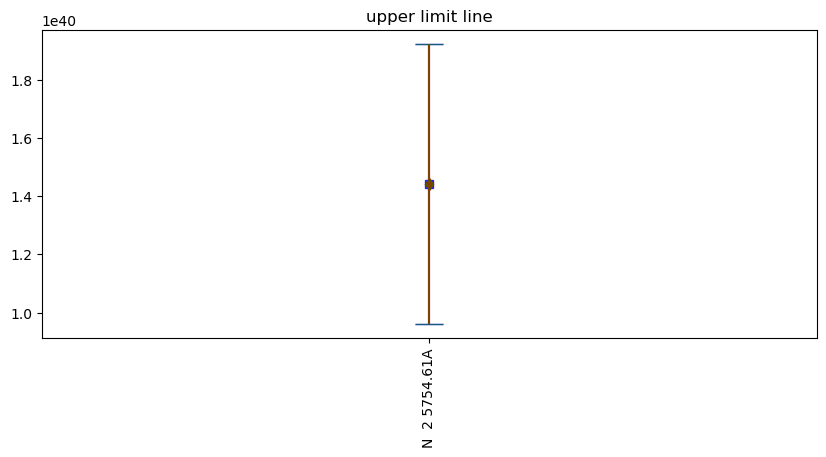

In [45]:
plt.figure(figsize=(10,4))
plt.title("upper limit line")
for line in range(len(og_obs["line_name"])):
    if fluxSN_obs["line_lum_up"][line] != 0:
        plt.errorbar(og_obs["line_name"][line], og_obs["line_lum_up"][line], yerr=og_obs["line_lum_unc"][line], marker = "s", capsize=10, alpha = 0.8, color = "blue")
        plt.errorbar(test_obs["line_name"][line], test_obs["line_lum_up"][line], yerr=test_obs["line_lum_unc"][line], marker = "d", color = "red")
        plt.errorbar(fluxSN_obs["line_name"][line], fluxSN_obs["line_lum_up"][line], yerr=fluxSN_obs["line_lum_unc"][line], marker = "d", capsize=10, alpha = 0.5,color = "green")
        
plt.xticks(rotation=90)
plt.show()

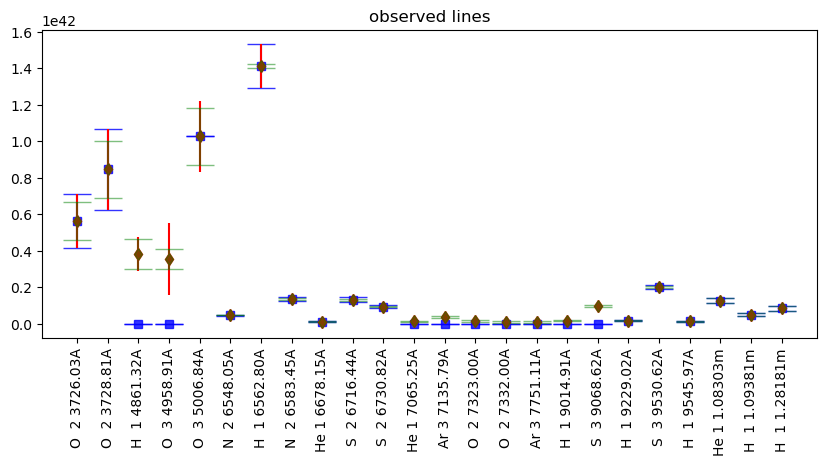

In [46]:
plt.figure(figsize=(10,4))
plt.title("observed lines")
for line in range(len(og_obs["line_name"])):
    if test_obs["line_lum"][line] != 0:
        plt.errorbar(og_obs["line_name"][line], og_obs["line_lum"][line], yerr=og_obs["line_lum_unc"][line], marker = "s", capsize=10, alpha = 0.8, color = "blue")
        plt.errorbar(test_obs["line_name"][line], test_obs["line_lum"][line], yerr=test_obs["line_lum_unc"][line], marker = "d", color = "red")
        plt.errorbar(fluxSN_obs["line_name"][line], fluxSN_obs["line_lum"][line], yerr=fluxSN_obs["line_lum_unc"][line], marker = "d", capsize=10, alpha = 0.5,color = "green")
        
plt.xticks(rotation=90)
plt.show()

not sure why bx587 o3 5007 uncertainty is so large... also, why is the flux sn so large still? 

also not sure why bx523 o3 5007 uncertainty is so large.

In [47]:
for line in range(len(og_obs["line_name"])):
    if fluxSN_obs["line_lum"][line] != 0:
        print("original", og_obs["line_name"][line], og_obs["line_lum"][line], og_obs["line_lum_unc"][line], "signal-to-noise",og_obs["line_lum"][line]/og_obs["line_lum_unc"][line] )
        print("test    ", test_obs["line_name"][line], test_obs["line_lum"][line], test_obs["line_lum_unc"][line], "signal-to-noise", test_obs["line_lum"][line]/test_obs["line_lum_unc"][line],)
        print("flux SN ", fluxSN_obs["line_name"][line], fluxSN_obs["line_lum"][line], fluxSN_obs["line_lum_unc"][line], "signal-to-noise", fluxSN_obs["line_lum"][line]/fluxSN_obs["line_lum_unc"][line])
        print("\n")

original O  2 3726.03A 5.640074625380761e+41 1.4686912142618321e+41 signal-to-noise 3.840204510391571
test     O  2 3726.03A 5.640074625380761e+41 1.4686912142618321e+41 signal-to-noise 3.840204510391571
flux SN  O  2 3726.03A 5.640074625380761e+41 1.0543544018090856e+41 signal-to-noise 5.349315766789033


original O  2 3728.81A 8.454949649083314e+41 2.2004376797803973e+41 signal-to-noise 3.842394504863739
test     O  2 3728.81A 8.454949649083314e+41 2.2004376797803973e+41 signal-to-noise 3.842394504863739
flux SN  O  2 3728.81A 8.454949649083314e+41 1.5808829318471947e+41 signal-to-noise 5.348245261402161


original H  1 4861.32A 0.0 0.0 signal-to-noise nan
test     H  1 4861.32A 3.81611036187618e+41 9.299818938032572e+40 signal-to-noise 4.103424364822633
flux SN  H  1 4861.32A 3.81611036187618e+41 8.15711225907144e+40 signal-to-noise 4.678261424724568


original O  3 4958.91A 0.0 0.0 signal-to-noise nan
test     O  3 4958.91A 3.551831192908834e+41 1.9544172855751487e+41 signal-to-noi

/tmp/ipykernel_1812209/2932995768.py:3: RuntimeWarning: invalid value encountered in scalar divide
  print("original", og_obs["line_name"][line], og_obs["line_lum"][line], og_obs["line_lum_unc"][line], "signal-to-noise",og_obs["line_lum"][line]/og_obs["line_lum_unc"][line] )
/tmp/ipykernel_1812209/2932995768.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  print("original", og_obs["line_name"][line], og_obs["line_lum"][line], og_obs["line_lum_unc"][line], "signal-to-noise",og_obs["line_lum"][line]/og_obs["line_lum_unc"][line] )


# comparing to my mosfire line lists

In [48]:
from astropy.io import fits
bagpipes_lineDir = "/home/carolinevr/CECILIA-MOS/mos-galaxies-nyx/scratch-wsl-ver/"
date = "09162025"
bagpipes_mcmc_scor = fits.open(bagpipes_lineDir+"cecilia_linelist_mos_mask_bagpipes_MCMC_scor_"+date+".fits") 
bagpipes_mcmc_scor_fluxes = bagpipes_mcmc_scor[1].data
bagpipes_mcmc_scor.close()
bagpipes_uncor = fits.open(bagpipes_lineDir+"cecilia_linelist_mos_mask_bagpipes_"+date+".fits") 
bagpipes_uncor_mos_fluxes = bagpipes_uncor[1].data
bagpipes_uncor.close()

In [49]:
new_bagpipes_uncor = fits.open("/home/carolinevr/CECILIA-MOS/mos-galaxies-nyx/bagpipes-noahspaper/cecilia_linelist_mos_mask_bagpipes_11262025.fits") 
new_bagpipes_uncor_mos_fluxes = new_bagpipes_uncor[1].data
new_bagpipes_uncor.close()

In [50]:
bx587_ind = (new_bagpipes_uncor_mos_fluxes["OBJNAME"]==galaxy)
print(galaxy, "uncor")
print("o2",new_bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007",new_bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959",new_bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb",new_bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1],new_bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])

fC23 uncor
o2 0.55045134 0.042187188 sn 15.552895
5007 0.7095412 0.04522446 sn 16.599682
4959 0.24551599 0.015648603 sn 16.599682
Hb 0.26516485 0.0475643 sn 6.234657
Ha 0.94420964 0.05253915 sn 16.998835


In [51]:
bx587_ind = (bagpipes_mcmc_scor_fluxes["OBJNAME"]==galaxy)
print(galaxy, "mcmc corr")
print("o2", bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][2],  "sn",bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007", bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][2], "sn", bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959", bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb", bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1], bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2],"sn", bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_mcmc_scor_fluxes["Halpha"][bx587_ind][0][2])

bx587_ind = (bagpipes_uncor_mos_fluxes["OBJNAME"]==galaxy)
print(galaxy, "uncor")
print("o2", bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O II]3726"][bx587_ind][0][2])
print("5007", bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]5007"][bx587_ind][0][2])
print("4959", bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["[O III]4959"][bx587_ind][0][2])
print("Hb", bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Hbeta"][bx587_ind][0][2])
print("Ha",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1], bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2],"sn",bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][1]/bagpipes_uncor_mos_fluxes["Halpha"][bx587_ind][0][2])

print(galaxy, "flux_SN luminosity file")
print("o2", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  2 3728.81A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  2 3728.81A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  2 3728.81A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  2 3728.81A')])
print("5007", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 5006.84A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 5006.84A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 5006.84A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 5006.84A')])
print("4959", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 4958.91A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 4958.91A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='O  3 4958.91A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='O  3 4958.91A')])
print("Hb", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 4861.32A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 4861.32A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 4861.32A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 4861.32A')])
print("Ha", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 6562.80A')], *fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 6562.80A')], "signal-to-noise", *fluxSN_obs["line_lum"][(fluxSN_obs["line_name"]=='H  1 6562.80A')]/fluxSN_obs["line_lum_unc"][(fluxSN_obs["line_name"]=='H  1 6562.80A')])

fC23 mcmc corr
o2 0.7654996 0.16388556 sn 4.67094
5007 1.2398857 0.2667538 sn 4.6480527
4959 0.4290262 0.09230235 sn 4.6480527
Hb 0.45745596 0.119626194 sn 3.8240452
Ha 2.271198 0.41020676 sn 5.536715
fC23 uncor
o2 0.3895157 0.025044579 sn 15.552895
5007 0.7149521 0.04307023 sn 16.599682
4959 0.24738826 0.014903193 sn 16.599682
Hb 0.26378164 0.042308927 sn 6.234657
Ha 0.94420964 0.05554555 sn 16.998835
fC23 flux_SN luminosity file
o2 8.454949649083314e+41 1.5808829318471947e+41 signal-to-noise 5.348245261402161
5007 1.026479214750653e+42 1.5767066687775586e+41 signal-to-noise 6.51027381996485
4959 3.551831192908834e+41 5.455732417915427e+40 signal-to-noise 6.51027381996485
Hb 3.81611036187618e+41 8.15711225907144e+40 signal-to-noise 4.678261424724568
Ha 1.412492692467002e+42 9.464887071461689e+39 signal-to-noise 149.23502856425173
